In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import yaml
import unicodedata
from helpers_finalizacion_carrera import get_egresados_computacion, plot_todos_anios_egreso, plot_tiempo_cursando, plot_todos_anios_egreso_solo_cantidad_y_k

In [2]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')
personas['dni'] = personas['dni'].astype(str)
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [3]:
#cambio los registros de la columna 'materia' para que esten en mayuscula, sin espacios al principio ni al final, y sin tildes.
actas['materia'] = actas['materia'].str.upper().str.strip()
actas['materia'] = actas['materia'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('ASCII'))

## Computación

In [4]:
materias_computacion = (
    actas[actas['carrera'] == 'Licenciatura en Ciencias de la Computación']['materia']
    .value_counts()
    .rename_axis('materia')
    .reset_index(name='cantidad')
)

materias_computacion

,materia,cantidad
0,ALGEBRA I,10599
1,ANALISIS II,7125
2,PROBABILIDADES Y ESTADISTICA,5038
3,ALGORITMOS Y ESTRUCTURAS DE DATOS II,4531
4,ALGORITMOS Y ESTRUCTURAS DE DATOS I,4362
...,...,...
350,REDUCCIONES Y CAUSALIDAD,1
351,FISICA DE ESTADISTICA DE LOS SISTEMAS SOCIO-EC...,1
352,MODELOS MATEMATICOS Y OPTIMIZACION,1
353,INTRODUCCION A LA FOTOGRAFIA 3D,1


In [5]:
with open('../../constants/materias_computacion.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias = [m for plan in config['planes'] for m in plan['materias']]

In [6]:
materias = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias]
materias = list(set(materias))
materias

['INGENIERIA DE SOFTWARE II',
 'PRACTICA SOCIAL EDUCATIVA',
 'TESIS DE LICENCIATURA',
 'SEMINARIO SOBRE TECNOLOGIA Y SOCIEDAD',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS I',
 'TEORIA DE LAS COMUNICACIONES',
 'LENGUAJES FORMALES, AUTOMATAS Y COMPUTABILIDAD',
 'PROGRAMACION CONCURRENTE Y PARALELA',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS',
 'ALMACENAMIENTO Y RECUPERACION DE LA INFORMACION',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS II',
 'TEORIA DE LENGUAJES',
 'ANALISIS II',
 'PROBABILIDADES Y ESTADISTICA',
 'COMPLEJIDAD COMPUTACIONAL',
 'ORGANIZACION DEL COMPUTADOR I',
 'LOGICA Y COMPUTABILIDAD',
 'SISTEMAS OPERATIVOS',
 'ESTADISTICA COMPUTACIONAL',
 'ANALISIS I',
 'TECNICAS DE DISENO DE ALGORITMOS',
 'BASE DE DATOS',
 'INTRODUCCION A LA PROGRAMACION',
 'ALGEBRA I',
 'INGENIERIA DE SOFTWARE',
 'ALGEBRA LINEAL COMPUTACIONAL',
 'PARADIGMAS DE PROGRAMACION',
 'METODOS NUMERICOS',
 'ARQUITECTURA Y ORGANIZACION DE COMPUTADORES',
 'ORGANIZACION DEL COMPUTADOR II',
 'INGENIERIA DE SOFTWARE I',
 'SISTEMAS DIG

In [7]:
len(materias)

34

In [8]:
materias_computacion[materias_computacion['materia'].isin(materias)].shape

(29, 2)

No todas las carreras aparecen, revisamos cuales faltan

In [9]:
materias_en_actas = materias_computacion['materia'].tolist()

In [10]:
[m for m in materias if m not in materias_en_actas]

['PRACTICA SOCIAL EDUCATIVA',
 'PROGRAMACION CONCURRENTE Y PARALELA',
 'ALMACENAMIENTO Y RECUPERACION DE LA INFORMACION',
 'ESTADISTICA COMPUTACIONAL',
 'REDES DE COMUNICACIONES Y COMPUTO DISTRIBUIDO']

In [11]:
materias_computacion[materias_computacion['materia'].isin(materias)].sort_values(by='cantidad', ascending=False).shape

(29, 2)

Todas se corresponden con materias del nuevo plan de computación, que ninguna de las materias puede estar indicando que todavía no se dieron.

A su vez, todas estas materias tienen correlativa excepto 'PRACTICA SOCIAL EDUCATIVA'. Esto nos daría el indicio de que no hay egresados con el nuevo plan todavía.

## Calculo de egresados

* Condición 1: el DNI tiene "TESIS DE LICENCIATURA" --> se considera que se recibió en ese año
* Condición 2: el DNI no tiene "TESIS DE LICENCIATURA" pero aprobó al menos 'min_materias_obligatorias' materias del listado Y al menos 'min_materias_optativas' materias fuera del listado --> se considera que se recibió en el año de la última materia obligatoria aprobada

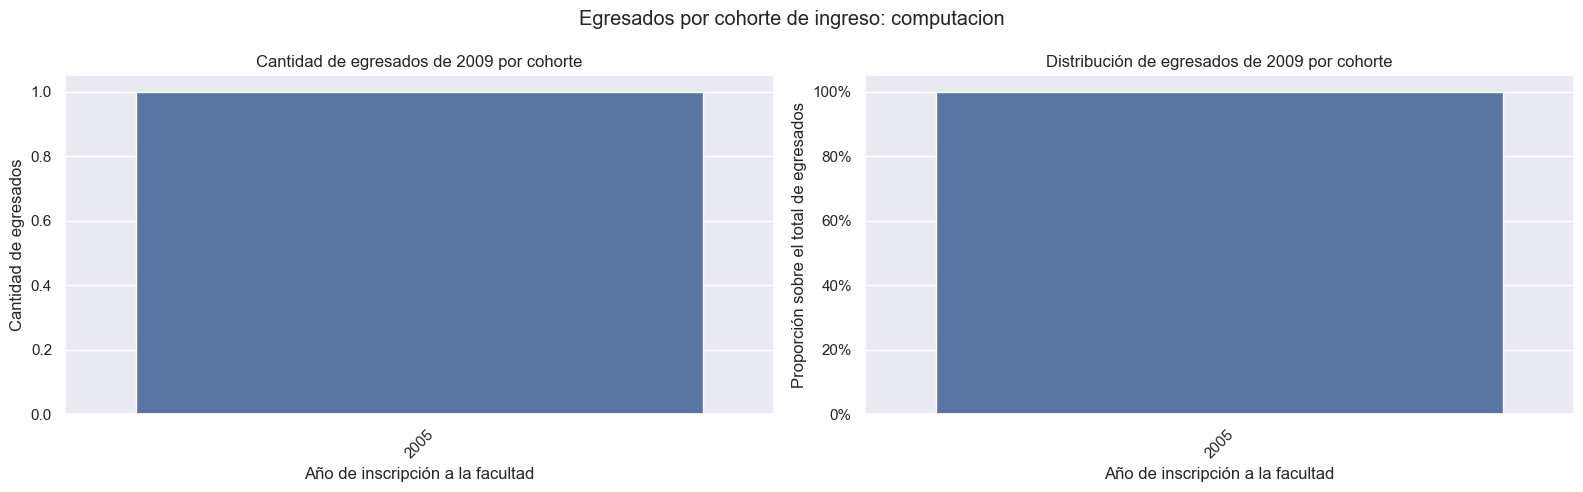

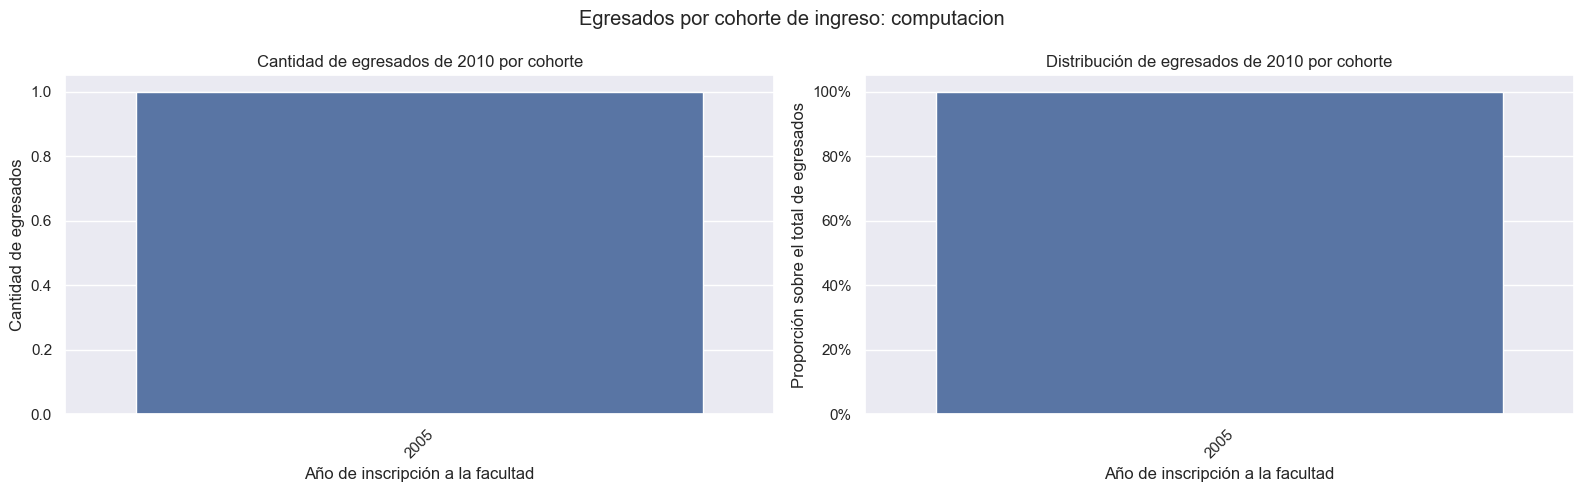

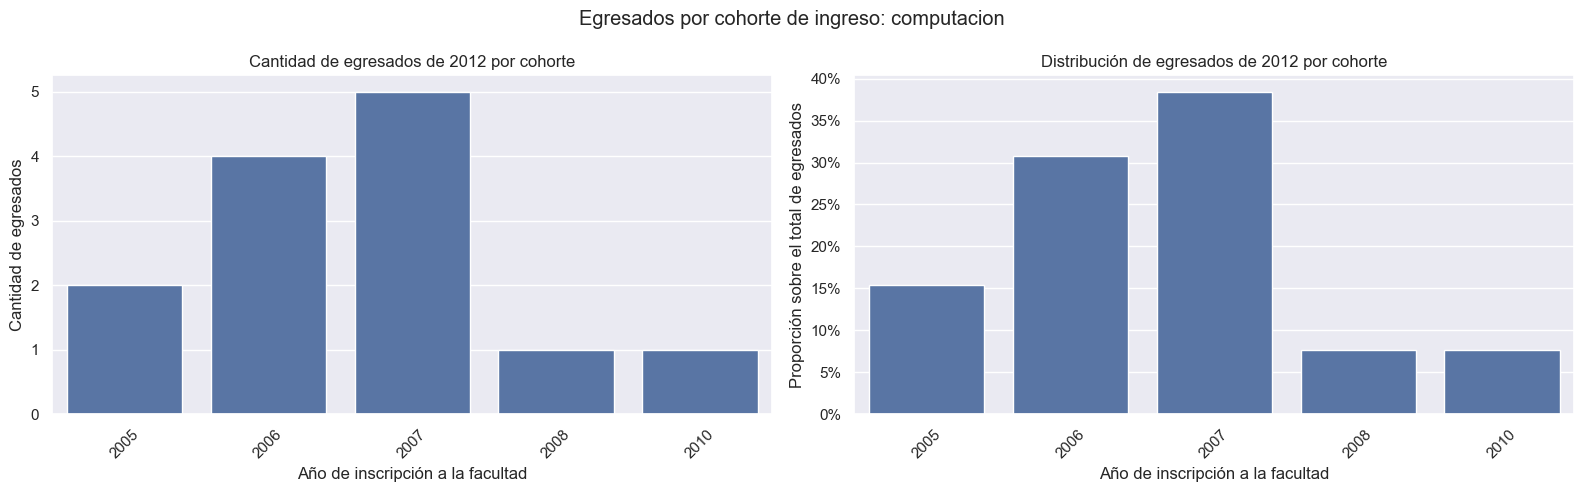

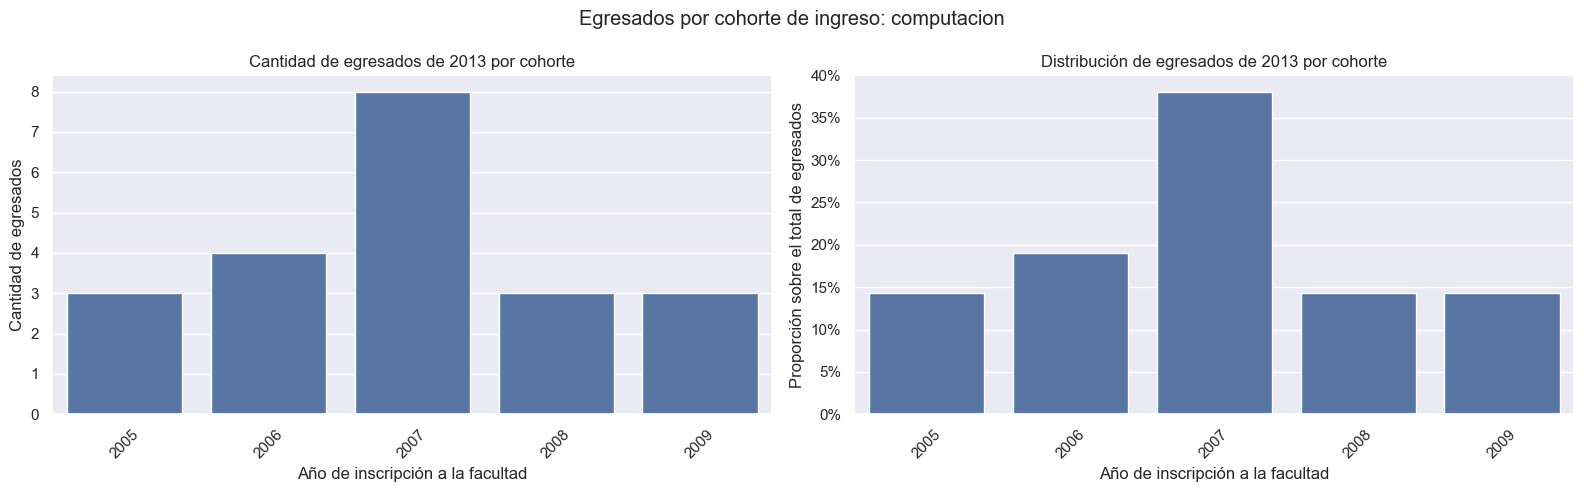

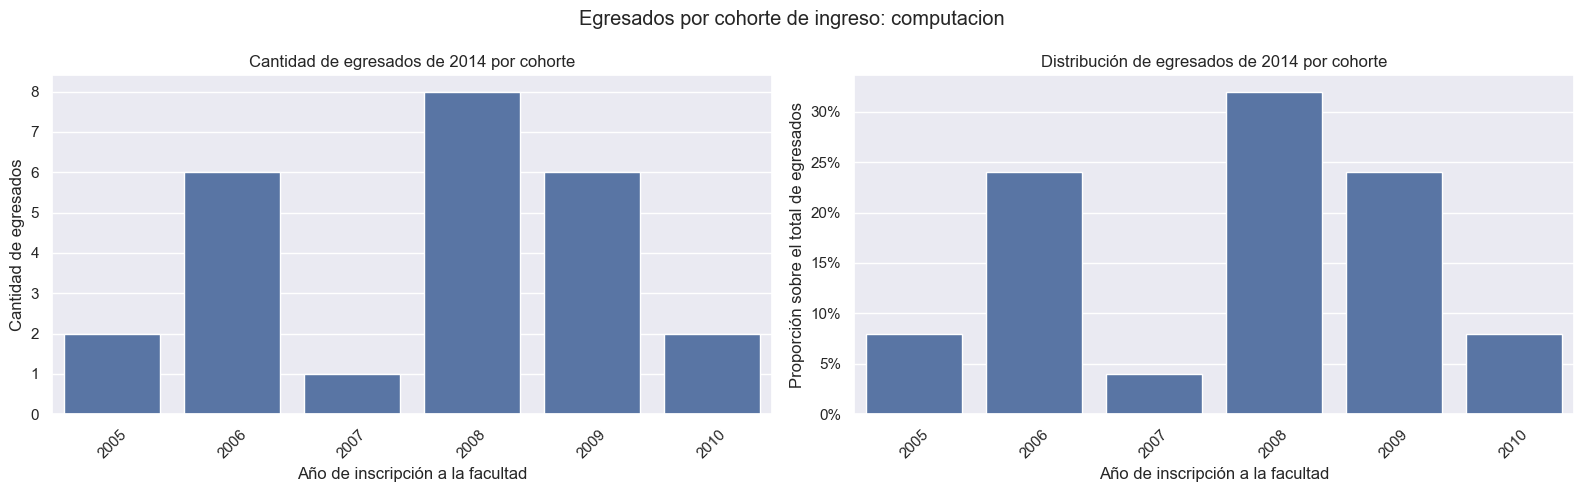

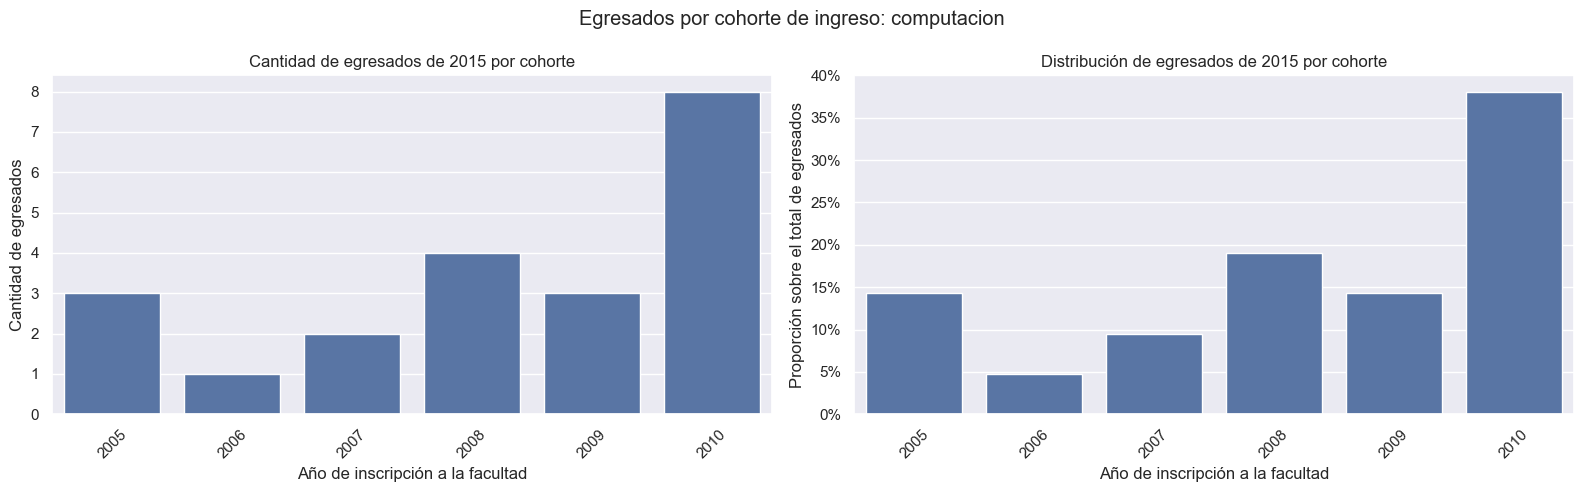

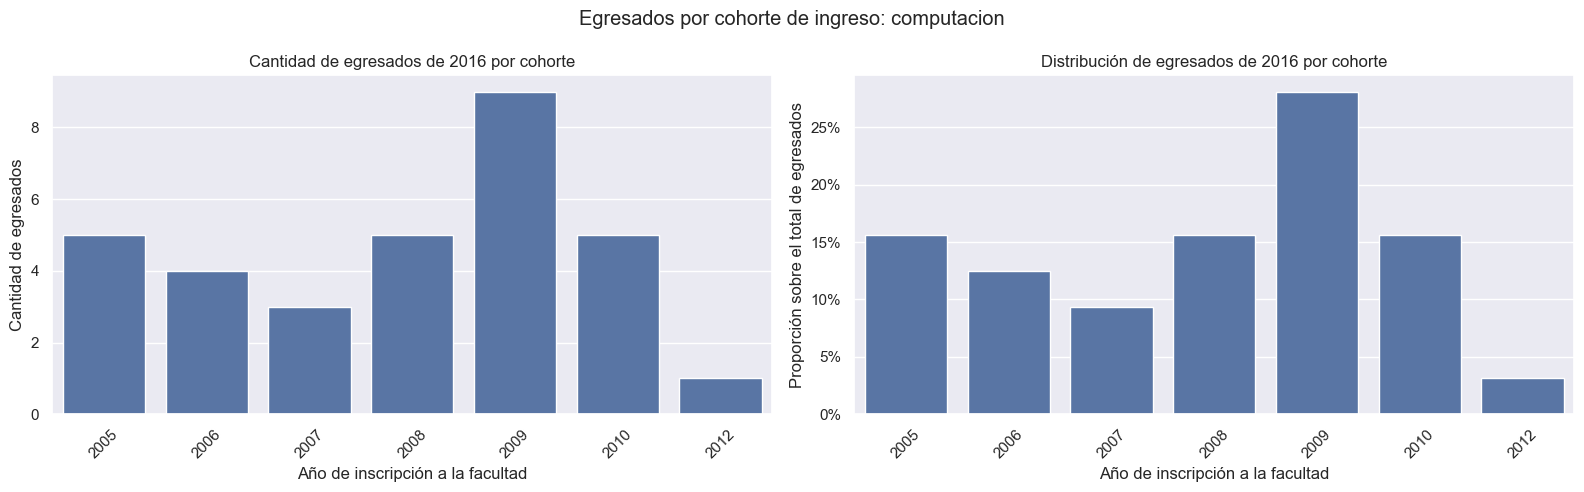

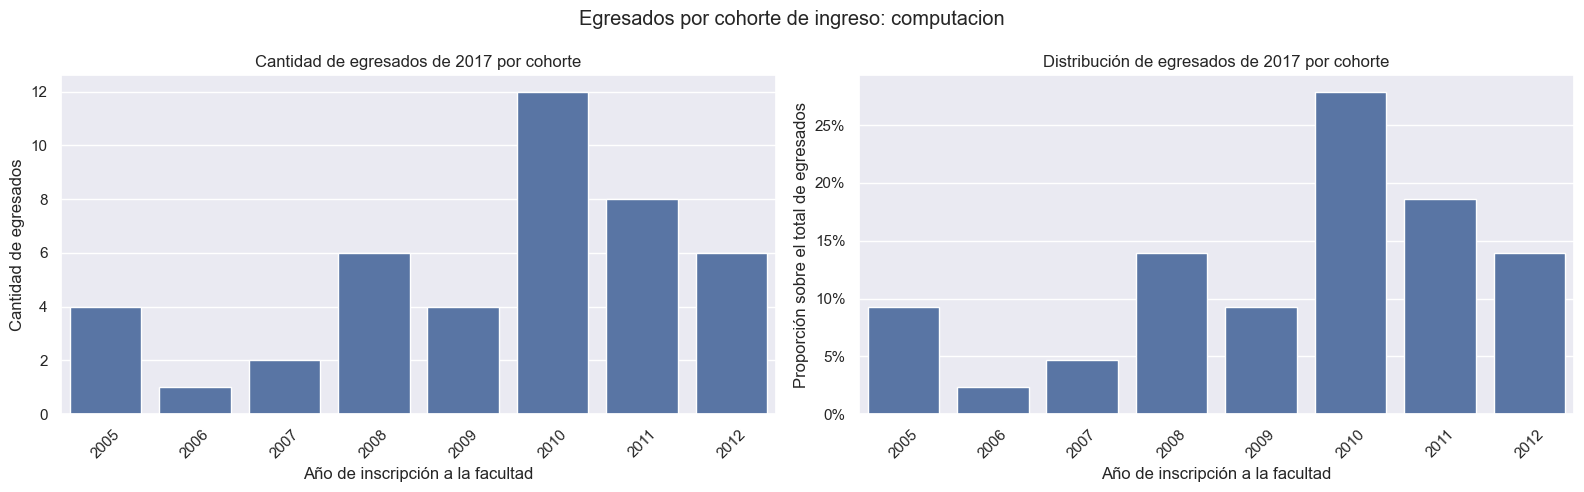

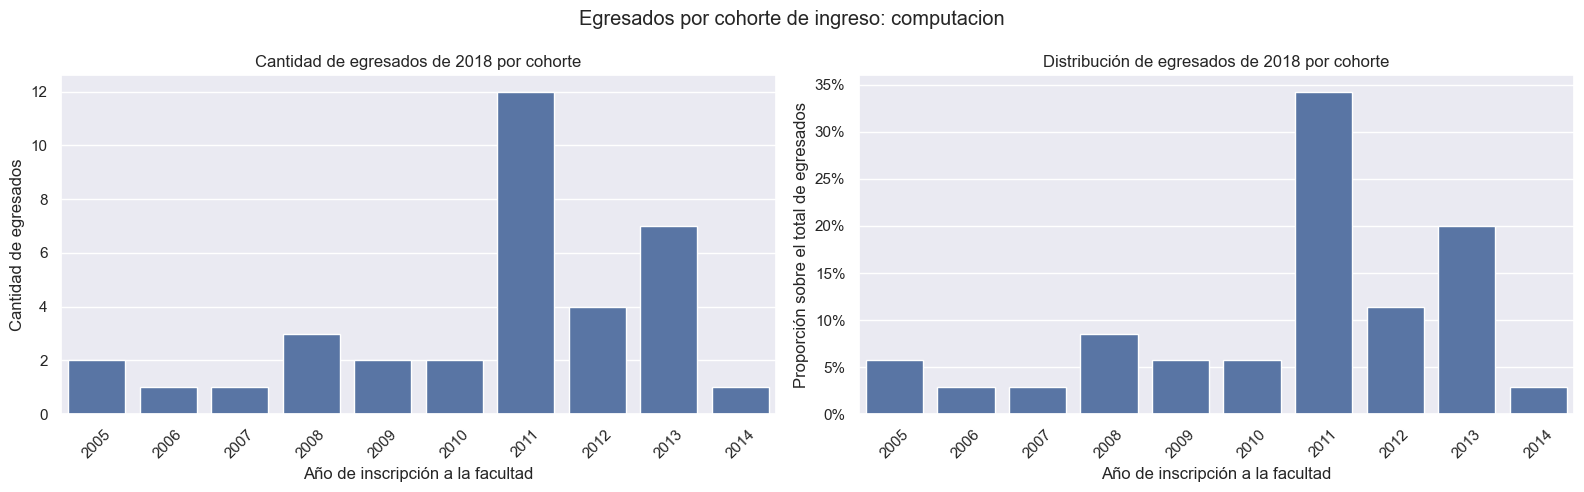

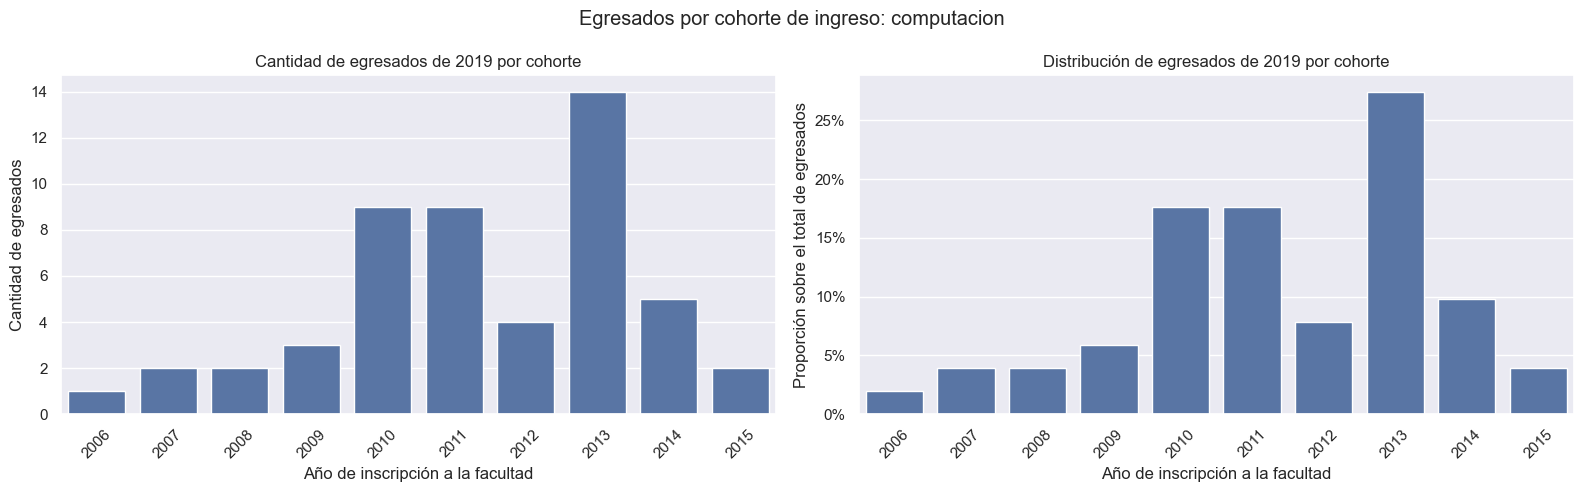

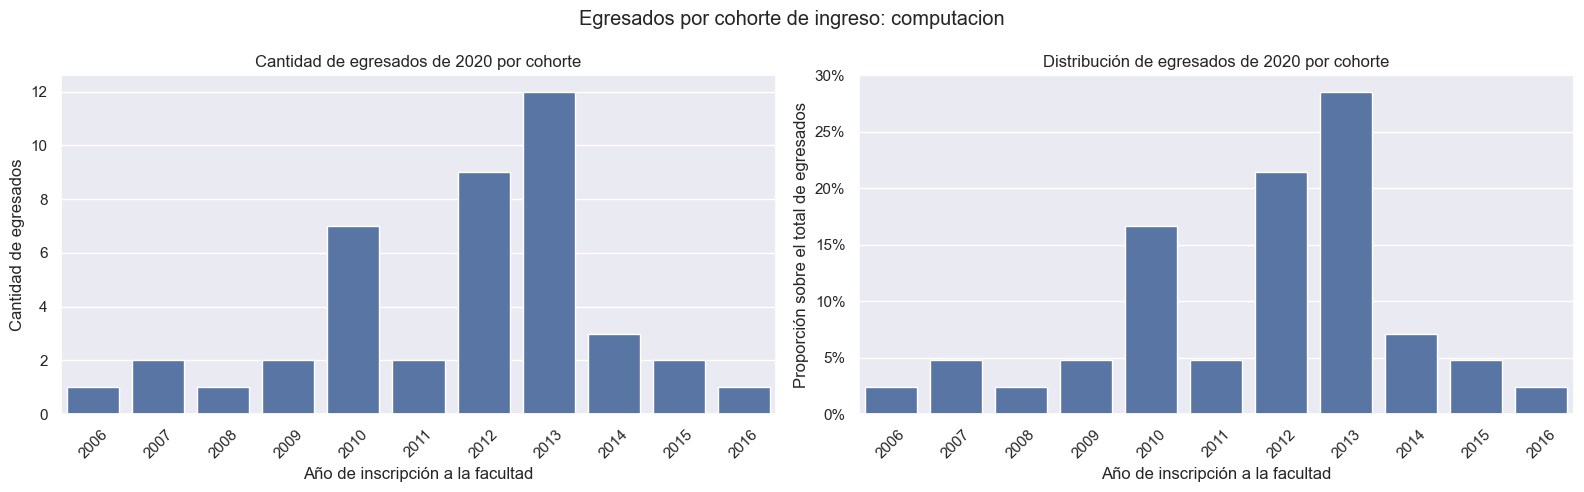

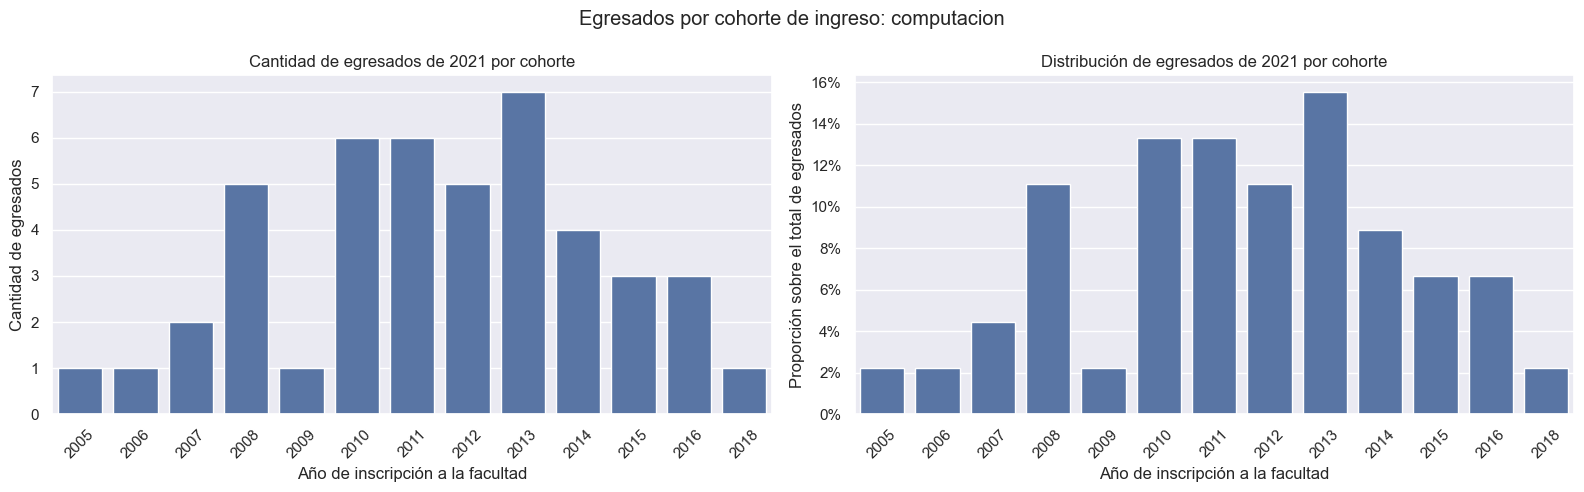

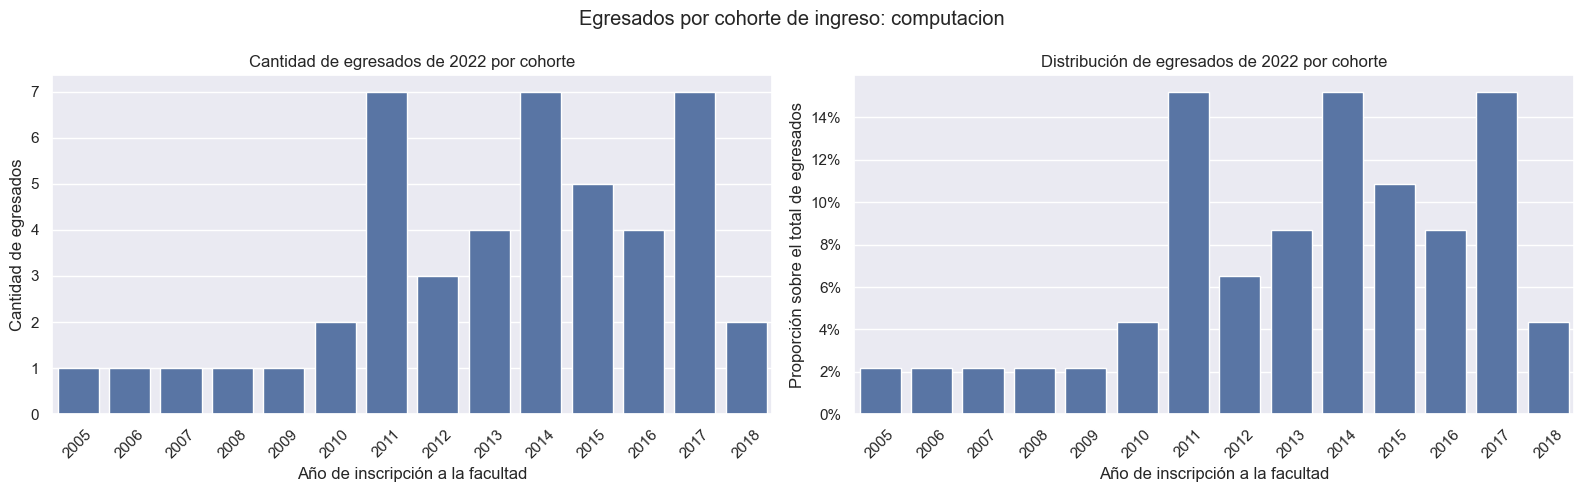

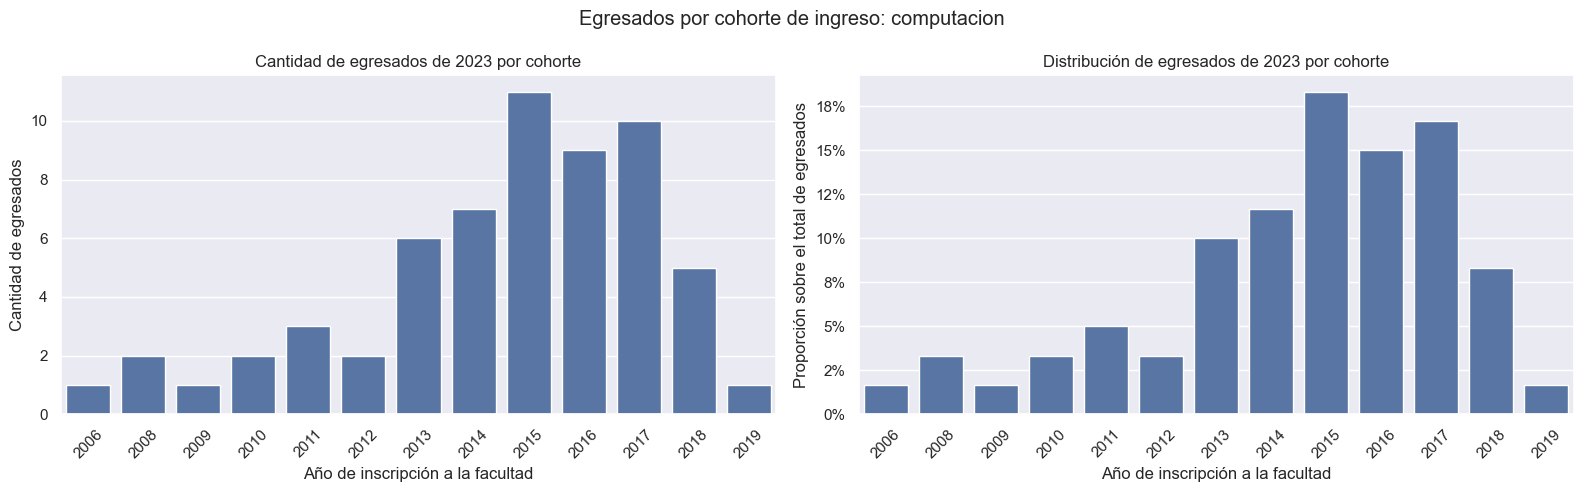

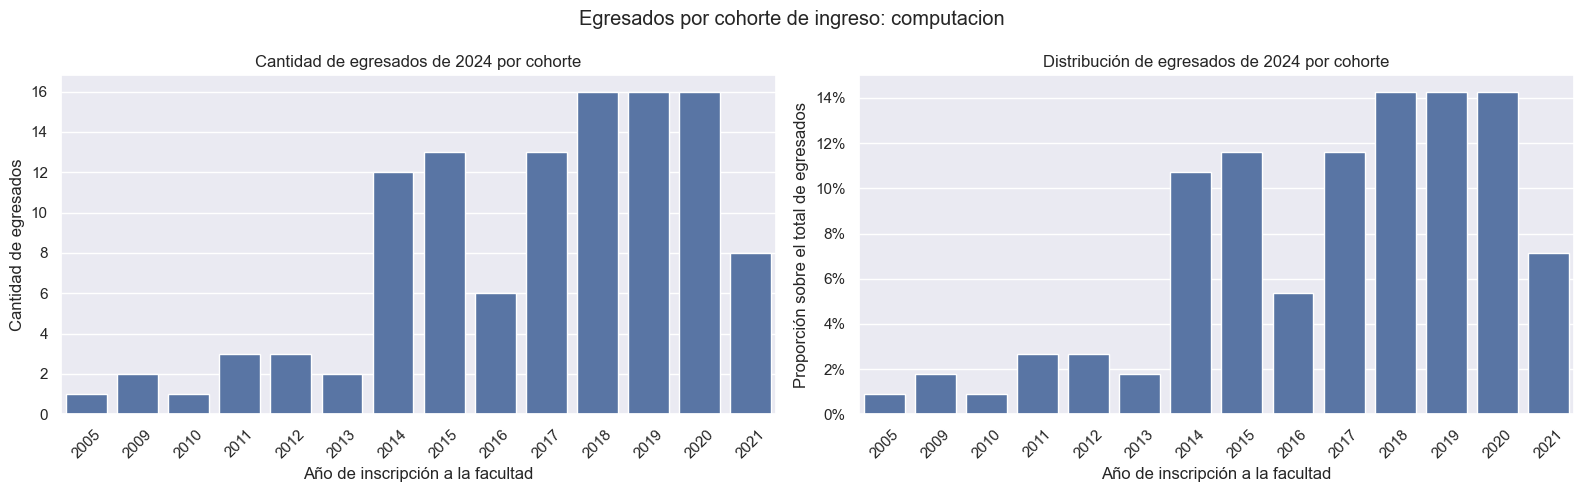

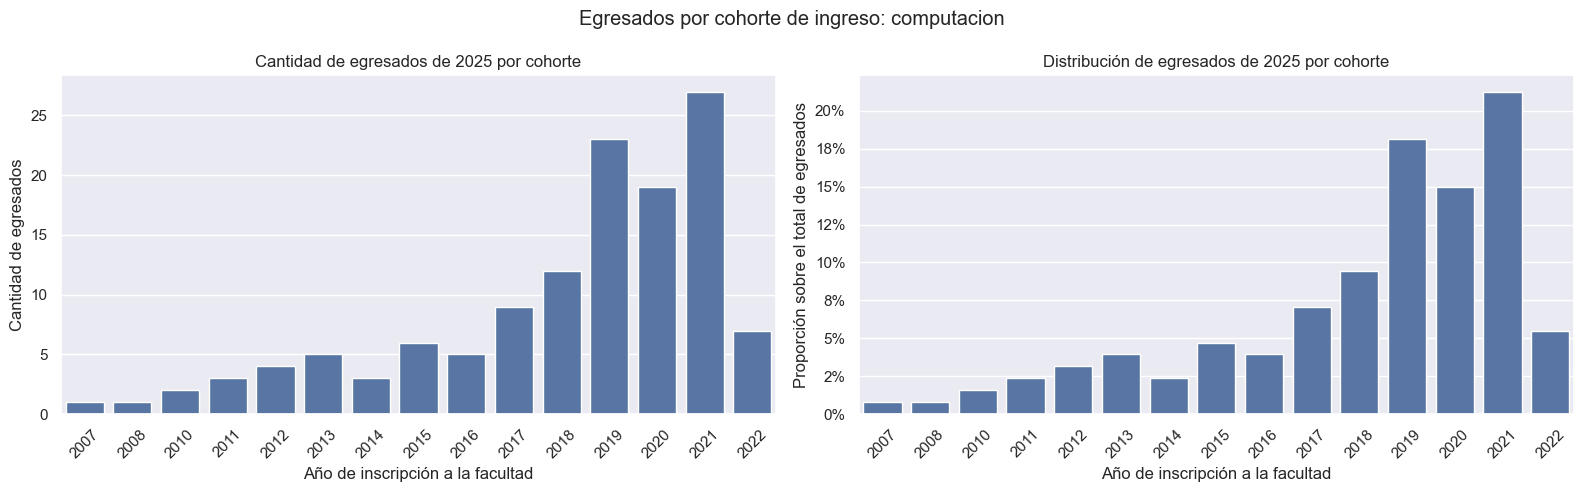

In [12]:
egresados = get_egresados_computacion(
    carreras=['Licenciatura en Ciencias de la Computación'],
    path_yaml='../../constants/materias_computacion.yaml',
    min_materias_obligatorias = 15,
    min_materias_optativas = 3,
    todos_los_planes = False
)
plot_todos_anios_egreso(egresados, 'Computación')

In [13]:
egresados_computacion_2014_2019 = pd.DataFrame()
for anio in range(2014, 2020):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/computacion/resumen_egresados_computacion_{anio}.csv')
    egresados_computacion_2014_2019 = pd.concat([egresados_computacion_2014_2019, egresados])

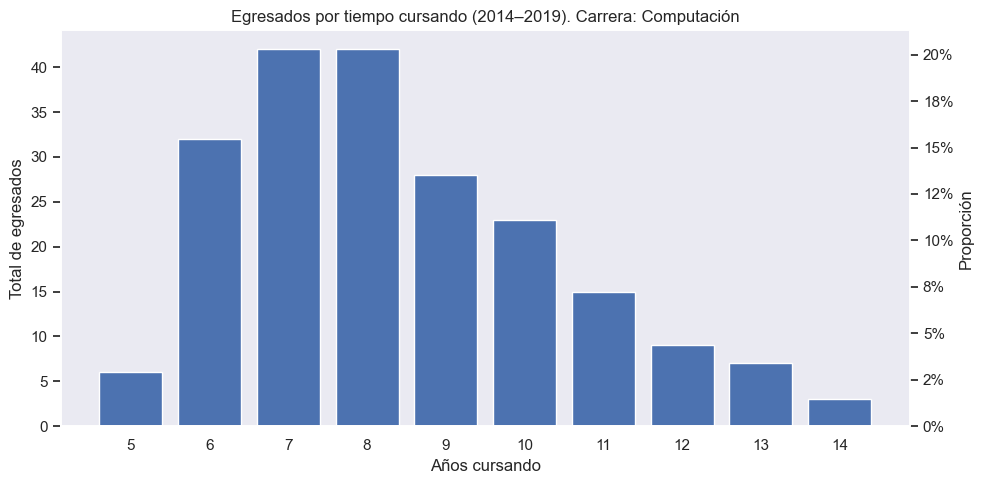

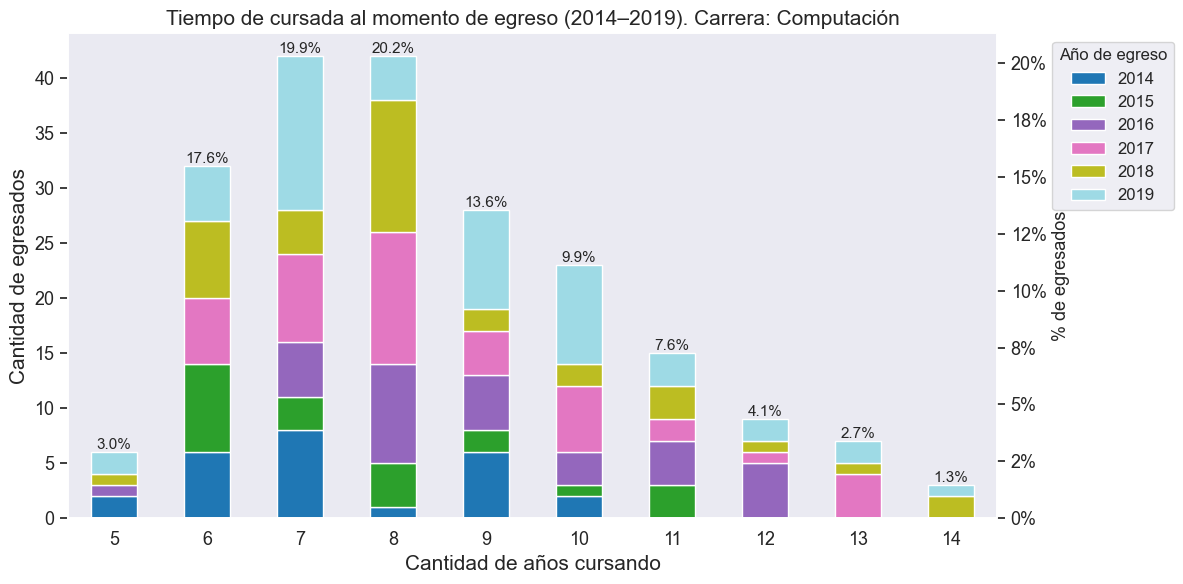

 tiempo_cursando  total_egreso
               5             6
               6            32
               7            42
               8            42
               9            28
              10            23
              11            15
              12             9
              13             7
              14             3
anio_egreso      2014  2015  2016  2017  2018  2019
tiempo_cursando                                    
5                   2     0     1     0     1     2
6                   6     8     0     6     7     5
7                   8     3     5     8     4    14
8                   1     4     9    12    12     4
9                   6     2     5     4     2     9
10                  2     1     3     6     2     9
11                  0     3     4     2     3     3
12                  0     0     5     1     1     2
13                  0     0     0     4     1     2
14                  0     0     0     0     2     1
Promedio ponderado de proporción po

In [ ]:
total_por_tiempo, resumen_por_cohorte, promedio_ponderado = plot_tiempo_cursando(egresados_computacion_2014_2019, 'Computación', anio_desde=2014, anio_hasta=2019)

## Modelo

In [15]:
import numpy as np
# 1. Creamos la serie expandida de años
datos_expandidos = np.repeat(total_por_tiempo['tiempo_cursando'], total_por_tiempo['total_egreso'])

# 2. Calculamos los límites del 95% (dejamos fuera 2.5% de cada lado)
limite_inferior = np.percentile(datos_expandidos, 2.5)
limite_superior = np.percentile(datos_expandidos, 97.5)

print(f"Rango recomendado para el 95%: {limite_inferior} a {limite_superior} años")

# 3. Filtramos el DataFrame original
df_filtrado = total_por_tiempo[
    (total_por_tiempo['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo['tiempo_cursando'] <= limite_superior)
]

Rango recomendado para el 95%: 5.15 a 13.0 años


In [16]:
from scipy.stats import chi2_contingency

resumen_por_cohorte_95 = resumen_por_cohorte[
    (resumen_por_cohorte.index >= limite_inferior) & 
    (resumen_por_cohorte.index <= limite_superior)
]

chi2, p, dof, expected = chi2_contingency(resumen_por_cohorte_95)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 65.88030988444697
p-value: 0.0012147232171733316


In [17]:
stats = {}

for col in resumen_por_cohorte_95.columns:
    datos = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[col])
    
    stats[col] = {
        "media": np.mean(datos),
        "mediana": np.median(datos),
        "std": np.std(datos)
    }

pd.DataFrame(stats).T

,media,mediana,std
2014,7.565217,7.0,1.345721
2015,7.714286,7.0,1.776644
2016,9.225806,9.0,1.717269
2017,8.604651,8.0,2.036179
2018,8.187500,8.0,1.844544
2019,8.625000,9.0,1.877776


In [18]:
import numpy as np

t_2014 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2014])
t_2015 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2015])
t_2016 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2016])
t_2017 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2017])
t_2018 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2018])
t_2019 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2019])

from scipy.stats import kruskal

kruskal(t_2014, t_2015, t_2016, t_2017, t_2018, t_2019)

KruskalResult(statistic=np.float64(15.547960978857512), pvalue=np.float64(0.008260467902721075))

In [19]:
import numpy as np
from scipy.stats import nbinom

total_por_tiempo_95 = total_por_tiempo[
    (total_por_tiempo['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo['tiempo_cursando'] <= limite_superior)
]

# 1. Expandir datos para cálculos estadísticos
datos_completos = np.repeat(total_por_tiempo_95["tiempo_cursando"], total_por_tiempo_95["total_egreso"])

# 2. Desplazar datos (Restamos el mínimo o la duración nominal, ej. 5)
shift = 5 
datos_desplazados = datos_completos - shift
# Nota: Si algún dato queda negativo (como el año 3), 
# se suele truncar a 0 o elegir un shift más pequeño.
datos_desplazados = np.maximum(datos_desplazados, 0)

mu = np.mean(datos_desplazados)
var = np.var(datos_desplazados)

print(f"Media: {mu:.2f}, Varianza: {var:.2f}")

if var > mu:
    # 3. Estimar parámetros n y p para la Binomial Negativa
    print("La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!")
    p = mu / var
    n = (mu**2) / (var - mu)
    print(f"Parámetros estimados: n={n:.2f}, p={p:.2f}")
else:
    print("Incluso desplazando, la varianza es menor. Considera una Binomial común.")

Media: 3.42, Varianza: 3.58
La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!
Parámetros estimados: n=76.46, p=0.96


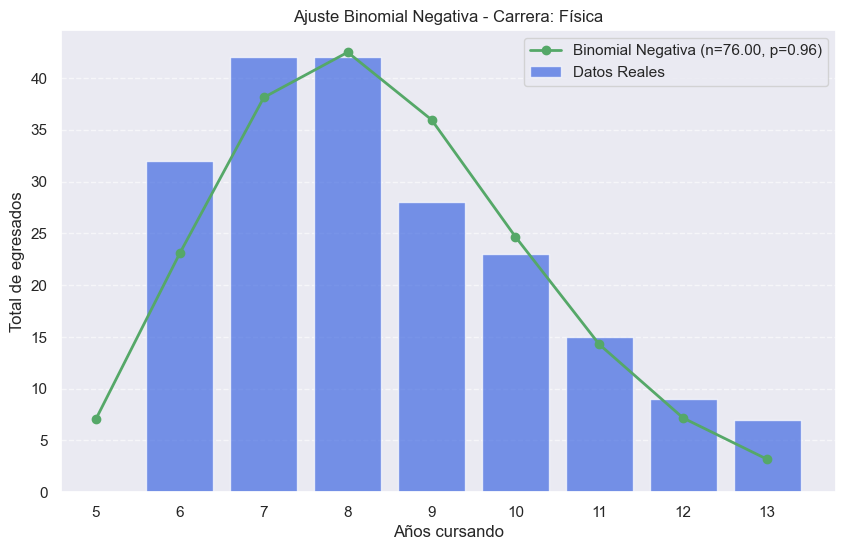

In [20]:
from scipy.stats import binom
import matplotlib.pyplot as plt
p_est = mu / var
n_est = int(round((mu**2) / (var - mu)))

# Eje X para la curva (desde el desplazamiento hacia adelante)
x_teorico = np.arange(0, total_por_tiempo_95['tiempo_cursando'].max() - shift + 1)
y_teorico = nbinom.pmf(x_teorico, n_est, p_est) * total_por_tiempo_95['total_egreso'].sum()

# 4. Graficamos
plt.figure(figsize=(10, 6))

# Barras reales
plt.bar(total_por_tiempo_95['tiempo_cursando'], total_por_tiempo_95['total_egreso'], color='royalblue', alpha=0.7, label='Datos Reales')

# Curva Binomial Negativa
# Nota: sumamos shift para devolver la curva a su posición original en el eje X
plt.plot(x_teorico + shift, y_teorico, 'go-', lw=2, 
            label=f'Binomial Negativa (n={n_est:.2f}, p={p_est:.2f})')

plt.title('Ajuste Binomial Negativa - Carrera: Física')
plt.xlabel('Años cursando')
plt.ylabel('Total de egresados')
plt.xticks(np.arange(int(round(limite_inferior)), int(round(limite_superior)) + 1, 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Ajuste de graficos

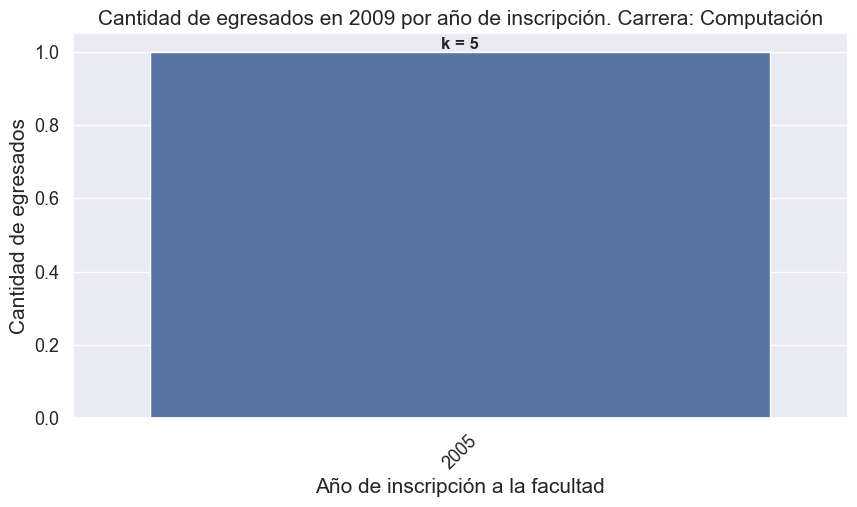

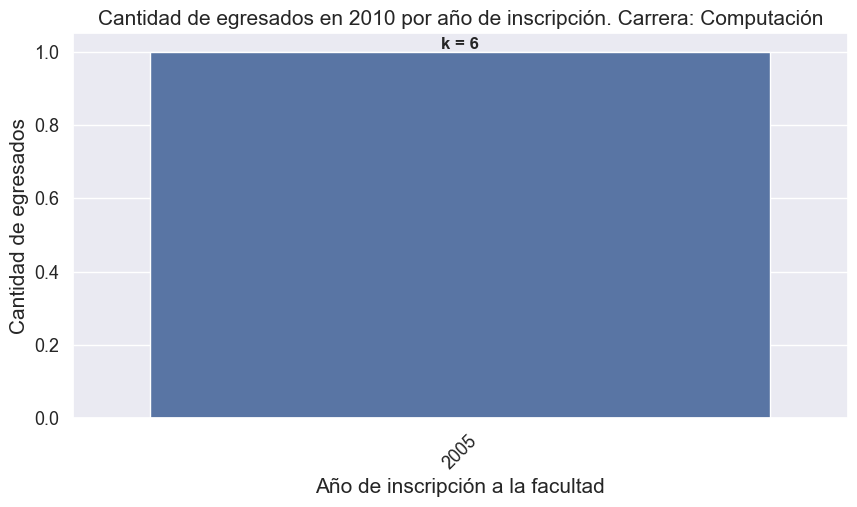

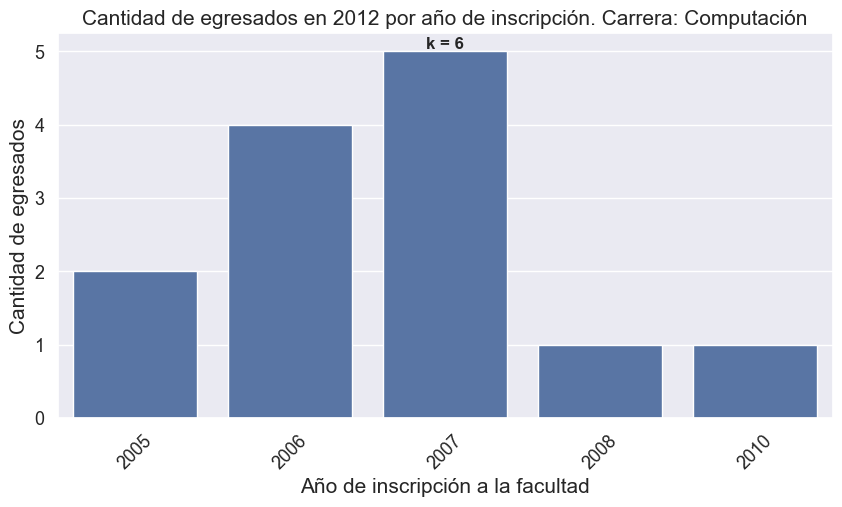

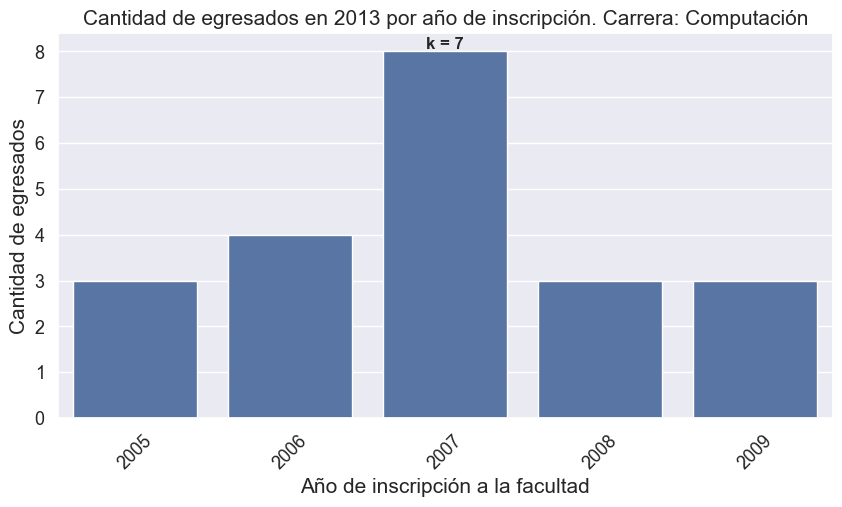

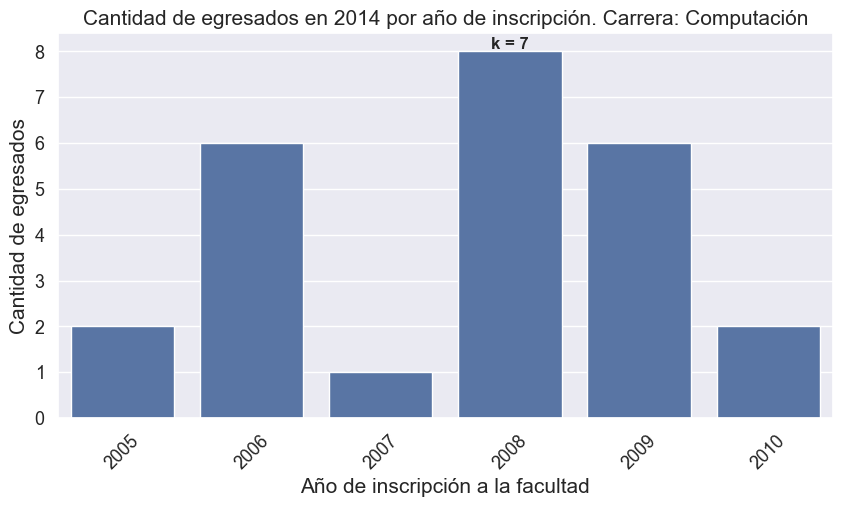

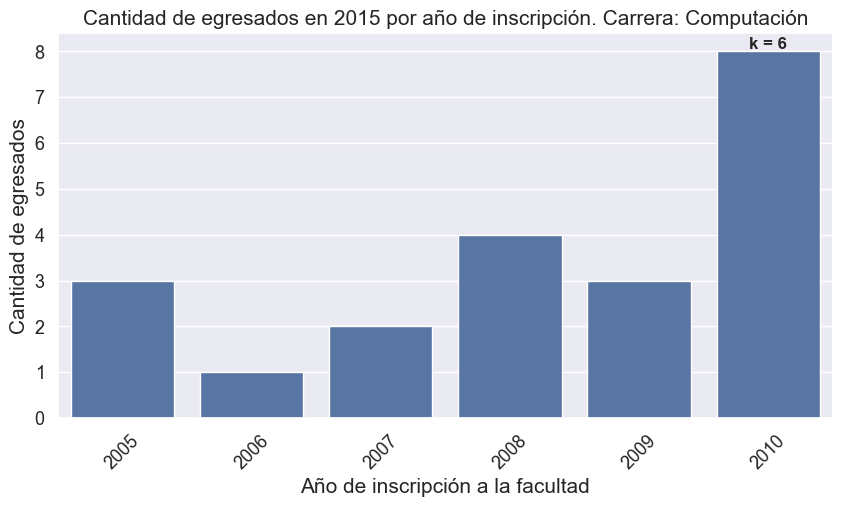

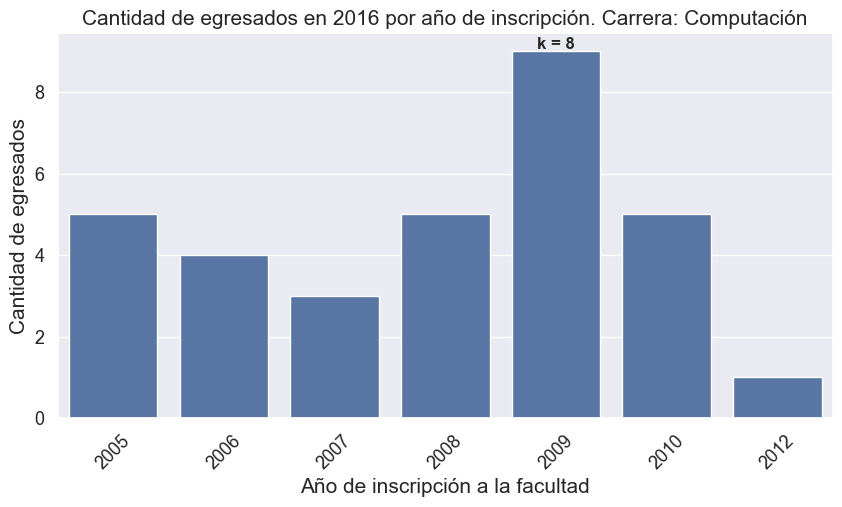

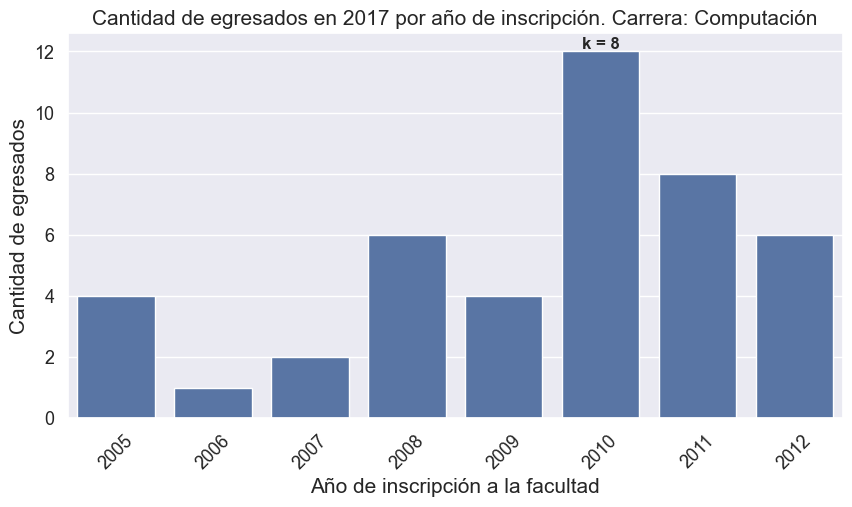

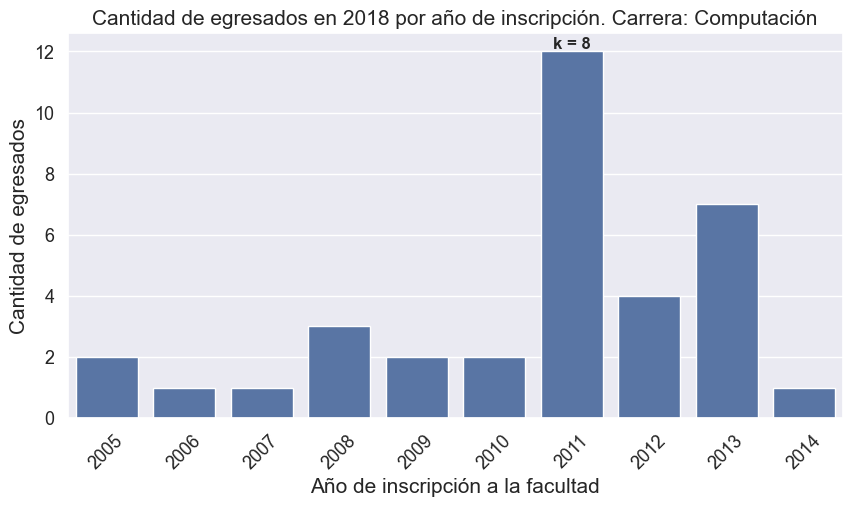

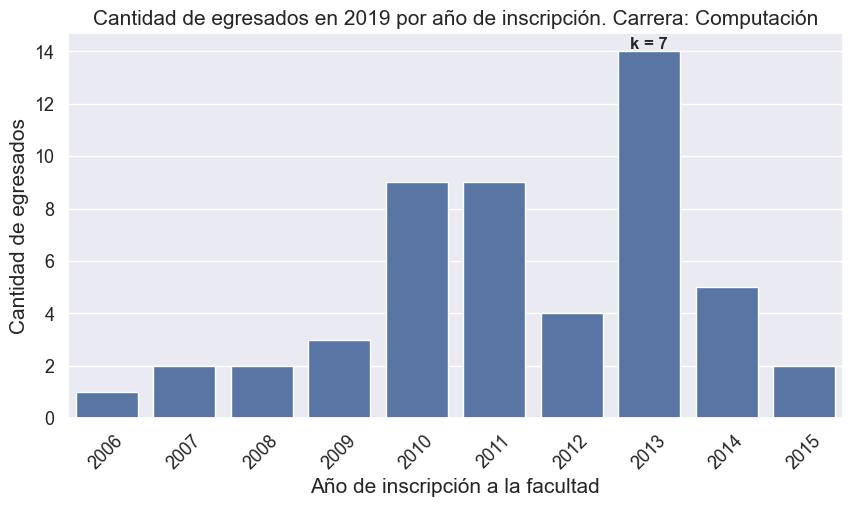

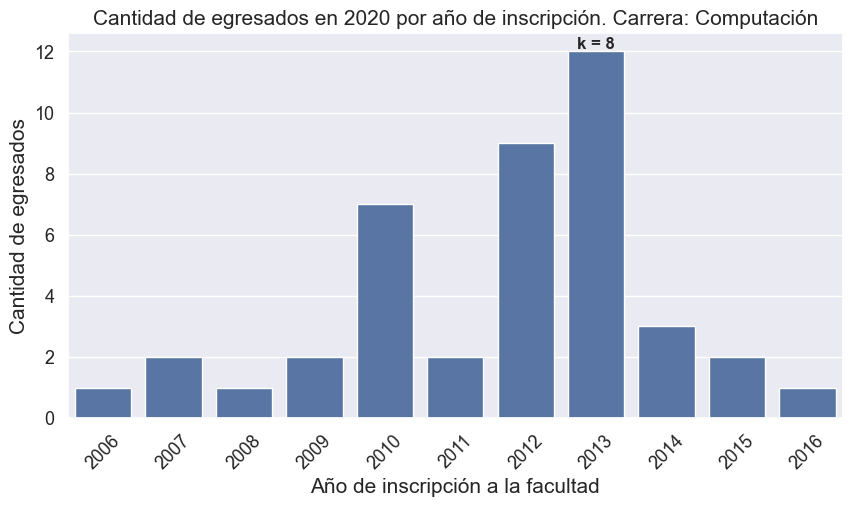

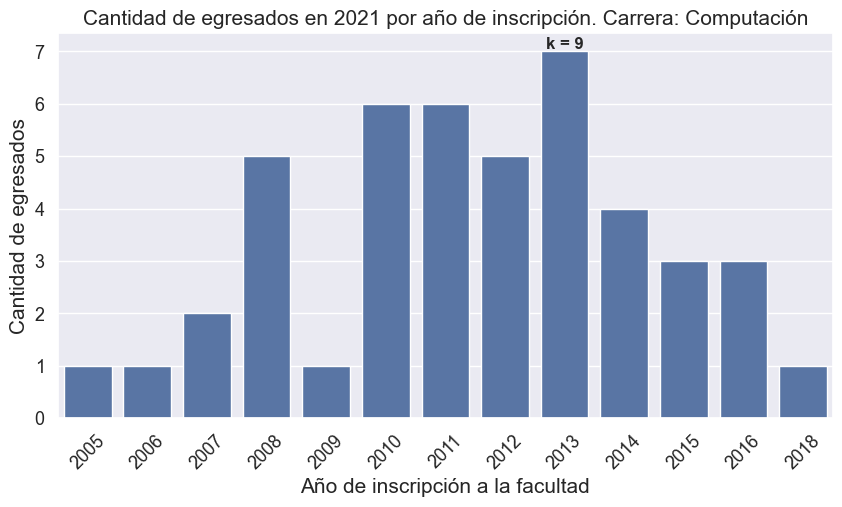

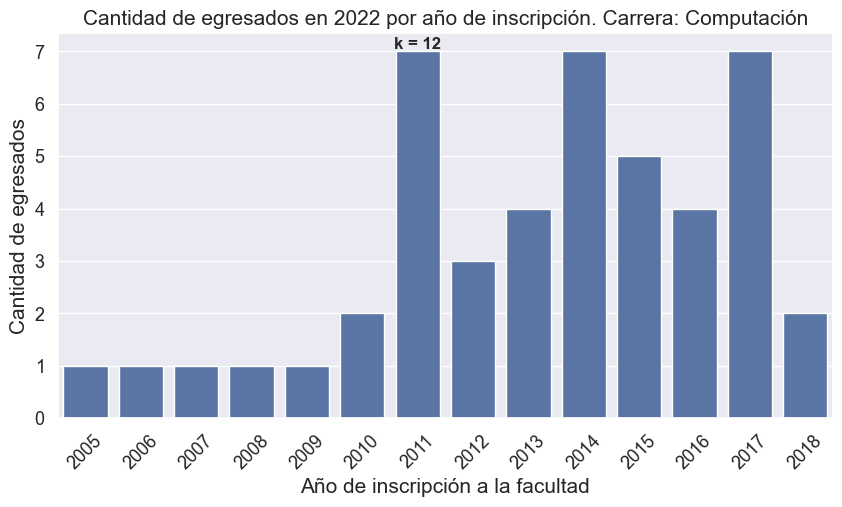

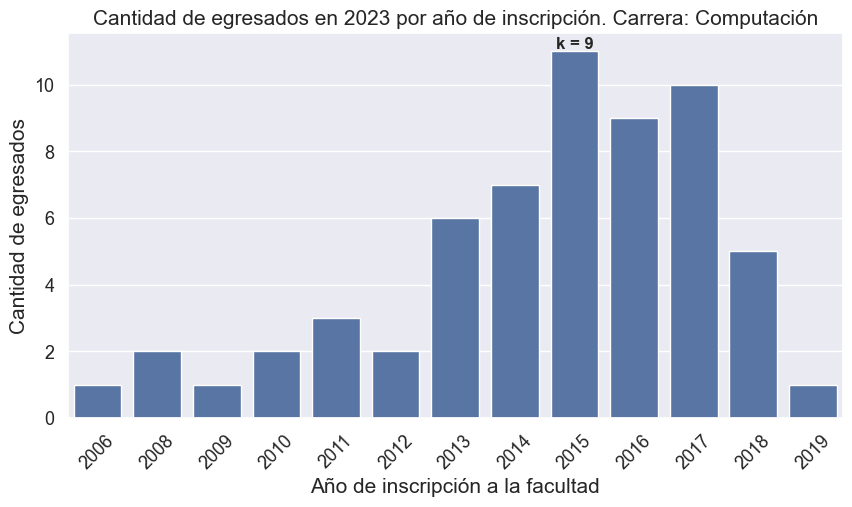

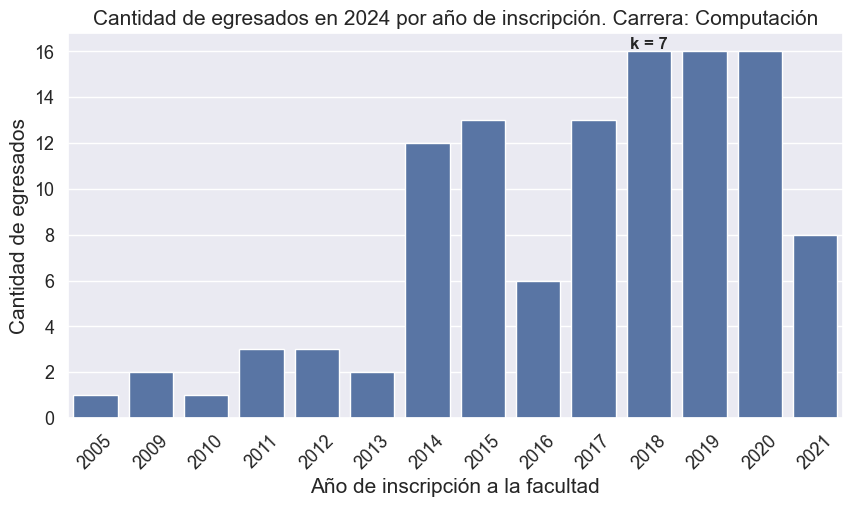

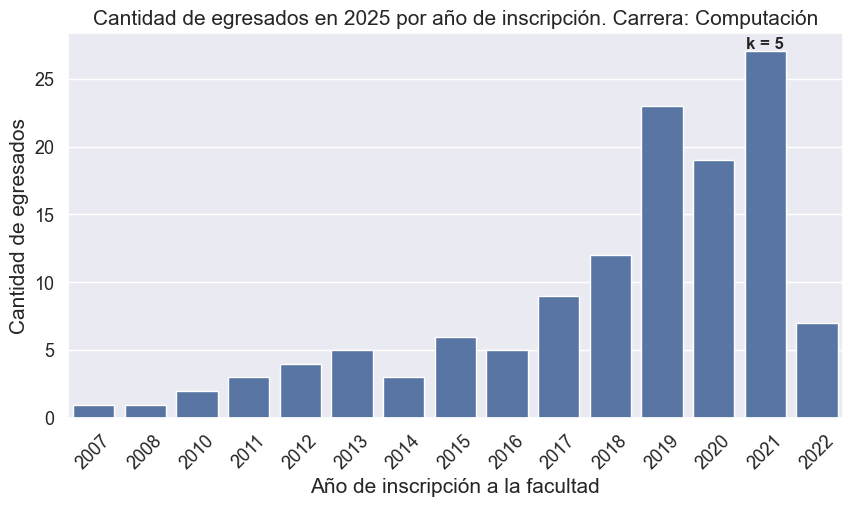

In [2]:
plot_todos_anios_egreso_solo_cantidad_y_k(2009, 2025, "Computación")